<a href="https://colab.research.google.com/github/AmalKhairalla/ML2-Activity-3/blob/main/pca%2Bdbscan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DBSCAN + PCA ASSIGNMENT (STUDENT)

## 1. Import libraries

In [60]:
!pip install mglearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 581.4/581.4 kB 12.1 MB/s eta 0:00:00


In [61]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import mglearn
# TODO: import required sklearn modules

## 2. Load Dataset

In [11]:
# TODO: load dataset
iris = load_iris()
df = pd.DataFrame(data = iris.data , columns= iris.feature_names)
df["speices"] = iris.target
print(df.head())

   sepal length (cm)  sepal width (cm)  ...  petal width (cm)  speices
0                5.1               3.5  ...               0.2        0
1                4.9               3.0  ...               0.2        0
2                4.7               3.2  ...               0.2        0
3                4.6               3.1  ...               0.2        0
4                5.0               3.6  ...               0.2        0

[5 rows x 5 columns]


## 3. Preprocessing

In [ ]:
# TODO:
# - Drop unnecessary columns
# - Handle missing values
# - Apply scaling
X_scaled = None

In [44]:
print( f"The shape of the Iris dataframe {df.shape}")
print(f"Numbers of rows (samples): {df.shape[0]}")
print(f"Numbers of columns (features + target): {df.shape[1]}")

The shape of the Iris dataframe (150, 5)
Numbers of rows (samples): 150
Numbers of columns (features + target): 5


In [20]:
df.corr()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),speices
sepal length (cm),1.000000,-0.117570,0.871754,0.817941,0.782561
sepal width (cm),-0.117570,1.000000,-0.428440,-0.366126,-0.426658
petal length (cm),0.871754,-0.428440,1.000000,0.962865,0.949035
petal width (cm),0.817941,-0.366126,0.962865,1.000000,0.956547
speices,0.782561,-0.426658,0.949035,0.956547,1.000000


The features are highly correlated with the target so i will keep them all

In [19]:
print(f"There is {df.isna().sum().sum()} nan values")
df.isna().sum()

There is 0 nan values


,0
sepal length (cm),0
sepal width (cm),0
petal length (cm),0
petal width (cm),0
speices,0


In [43]:
X = df.drop(columns =["speices"])
y = df["speices"]

array([[<Axes: title={'center': 'sepal length (cm)'}>,
        <Axes: title={'center': 'sepal width (cm)'}>],
       [<Axes: title={'center': 'petal length (cm)'}>,
        <Axes: title={'center': 'petal width (cm)'}>]], dtype=object)

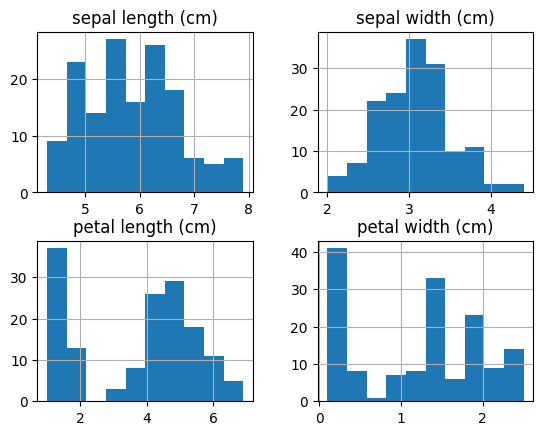

In [45]:
X.hist()

In [50]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(X)
x_scaled = pd.DataFrame(data = scaled_data , columns = X.columns )
x_scaled

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,-0.900681,1.019004,-1.340227,-1.315444
1,-1.143017,-0.131979,-1.340227,-1.315444
2,-1.385353,0.328414,-1.397064,-1.315444
3,-1.506521,0.098217,-1.283389,-1.315444
4,-1.021849,1.249201,-1.340227,-1.315444
...,...,...,...,...
145,1.038005,-0.131979,0.819596,1.448832
146,0.553333,-1.282963,0.705921,0.922303
147,0.795669,-0.131979,0.819596,1.053935
148,0.432165,0.788808,0.933271,1.448832


array([[<Axes: title={'center': 'sepal length (cm)'}>,
        <Axes: title={'center': 'sepal width (cm)'}>],
       [<Axes: title={'center': 'petal length (cm)'}>,
        <Axes: title={'center': 'petal width (cm)'}>]], dtype=object)

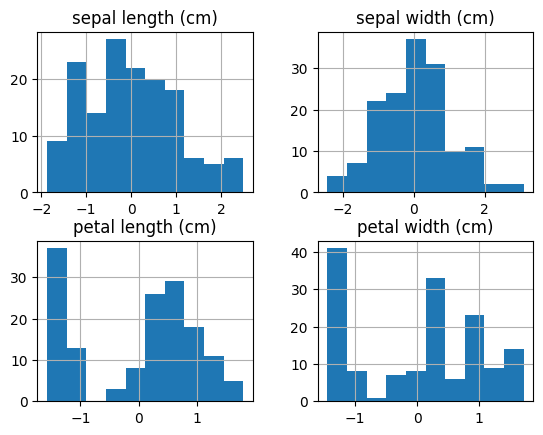

In [51]:
x_scaled.hist()

## 4. PCA

In [1]:
# TODO:
# - Apply PCA (2 components)
# - Print explained variance
X_pca = None
# TODO: Plot PCA

In [54]:
pca = PCA(n_components=2)

In [55]:
pca.fit(x_scaled)

PCA(n_components=2)

In [57]:
X_pca = pca.transform(x_scaled)
print("Original shape:", x_scaled.shape)
print("Reduced shape:", X_pca.shape)

Original shape: (150, 4)
Reduced shape: (150, 2)


Text(0, 0.5, 'Second principal component')

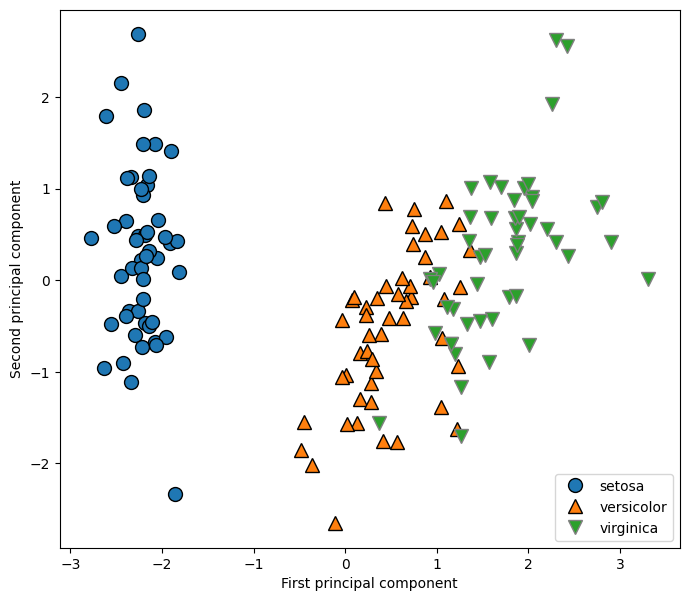

In [64]:
plt.figure(figsize=(8,8))
mglearn.discrete_scatter(X_pca[:,0], X_pca[:,1], iris.target)
plt.legend(iris.target_names, loc="best")
plt.gca().set_aspect("equal")
plt.xlabel("First principal component")
plt.ylabel("Second principal component")

In [67]:
print("PCA component shape:", pca.components_.shape)

PCA component shape: (2, 4)


In [68]:
print("PCA component:\n", pca.components_)

PCA component:
 [[ 0.52106591 -0.26934744  0.5804131   0.56485654]
 [ 0.37741762  0.92329566  0.02449161  0.06694199]]


In [69]:
print(pca.explained_variance_)
print(pca.explained_variance_ratio_)

[2.93808505 0.9201649 ]
[0.72962445 0.22850762]


## 5. DBSCAN (Original Data)

In [ ]:
# TODO:
# - Apply DBSCAN
# - Tune eps and min_samples
labels_original = None
# TODO: Plot clustering
# -------------------------------

## 6. DBSCAN (PCA Data)

In [ ]:
labels_pca = None
# TODO: Plot clustering

### 7. Analysis

In [ ]:
# TODO:
# - Compare results
# - Count clusters
# - Count noise points
print("Analysis goes here")